In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import torch
import numpy as np
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR


from common.data import DataWithLabels


In [2]:
dataset = DataWithLabels.from_npz(r'data/monte_carlo_configs.npz')

X              = dataset.x
Values         = dataset.values
Configurations = dataset.configurations
Energies       = dataset.energies
Labels         = dataset.labels

## Contrastive Learning

Epoch 1/100, Average Loss: 0.260362, Average Val Loss: 0.153868
Epoch 2/100, Average Loss: 0.156079, Average Val Loss: 0.055026
Epoch 3/100, Average Loss: 0.091260, Average Val Loss: 0.044849
Epoch 4/100, Average Loss: 0.072069, Average Val Loss: 0.042909


c:\Users\Vít\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 5/100, Average Loss: 0.062222, Average Val Loss: 0.035545
Epoch 6/100, Average Loss: 0.056997, Average Val Loss: 0.034793
Epoch 7/100, Average Loss: 0.050345, Average Val Loss: 0.038805
Epoch 8/100, Average Loss: 0.049877, Average Val Loss: 0.035939
Epoch 9/100, Average Loss: 0.047239, Average Val Loss: 0.030685
Epoch 10/100, Average Loss: 0.044349, Average Val Loss: 0.029016
Epoch 11/100, Average Loss: 0.040663, Average Val Loss: 0.024901
Epoch 12/100, Average Loss: 0.040443, Average Val Loss: 0.022095
Epoch 13/100, Average Loss: 0.039021, Average Val Loss: 0.022379
Epoch 14/100, Average Loss: 0.033560, Average Val Loss: 0.020327
Epoch 15/100, Average Loss: 0.033926, Average Val Loss: 0.019235
Epoch 16/100, Average Loss: 0.031618, Average Val Loss: 0.015799
Epoch 17/100, Average Loss: 0.030701, Average Val Loss: 0.014450
Epoch 18/100, Average Loss: 0.029610, Average Val Loss: 0.015301
Epoch 19/100, Average Loss: 0.028647, Average Val Loss: 0.014992
Epoch 20/100, Average Loss: 0.

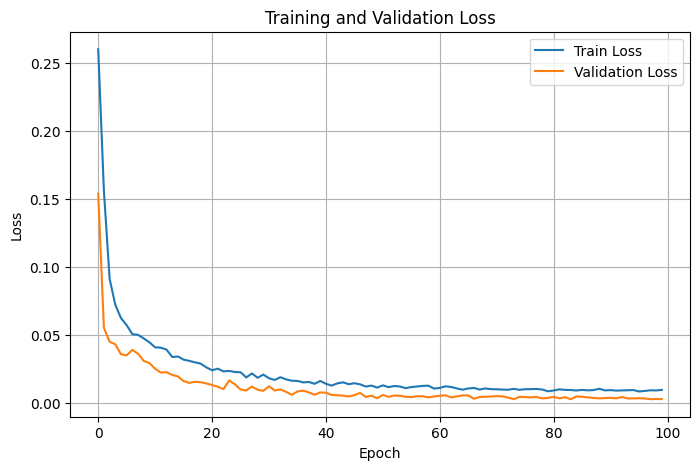

Embeddings shape: (6000, 2)


In [3]:
from contrastive_learning.model import SiameseNetwork, TrainConfig, train_model, get_embeddings
from contrastive_learning.dataset import make_balanced_train_test_dataset
from common.utils import plot_loss_curves

num_epochs = 100
warmup_epochs = max(1, int(0.05 * num_epochs))
EMBEDDING_SIZE = 2
train_loader, test_loader = make_balanced_train_test_dataset(
    Configurations, Labels, 
    batch_size=64, 
    train_ratio=0.8, 
    positive_ratio=0.5
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train = True
save_model = True
save_dir = Path('results')
save_dir.mkdir(exist_ok=True)
if train:
    model = SiameseNetwork(embedding_size=EMBEDDING_SIZE).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sched1 = LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=warmup_epochs)
    sched2 = CosineAnnealingLR(optimizer, T_max=(num_epochs - warmup_epochs))
    scheduler = SequentialLR(optimizer, schedulers=[sched1, sched2], milestones=[warmup_epochs])

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        train_loader=train_loader,
        test_loader=test_loader,
    )

    avg_loss, avg_val_loss = train_model(config, num_epochs=num_epochs, steps_per_epoch=50, margin=1.0)
    plot_loss_curves(avg_loss, avg_val_loss)
    if save_model:
        torch.save({
            'model_state_dict': model.state_dict(),
            'embedding_size': EMBEDDING_SIZE,
        }, save_dir / 'siamese_encoder.pt')
else:
    checkpoint = torch.load(save_dir / 'siamese_encoder.pt', map_location=device, weights_only=True)

    model = SiameseNetwork(embedding_size=checkpoint['embedding_size']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=None,
        scheduler=None,
        train_loader=None,
        test_loader=None,
    )

# Get embeddings for all configurations
all_embeddings = get_embeddings(config, Configurations)
print(f"Embeddings shape: {all_embeddings.shape}")

## Clustering

here, we shall cluster samples in the embedding space and compare to the original clustering.

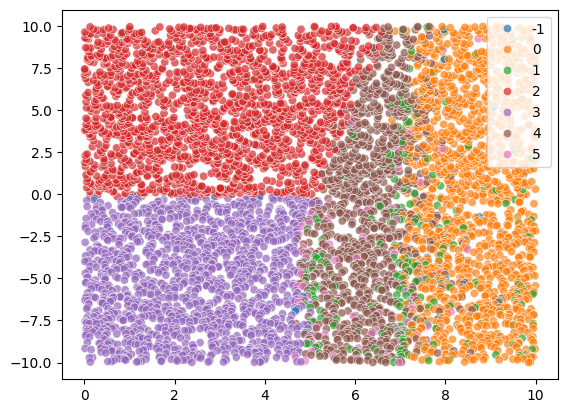

In [8]:
from hdbscan import HDBSCAN

hd_contr = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.018, cluster_selection_method='eom').fit(all_embeddings)
Labels_contr = hd_contr.labels_

ax = sns.scatterplot(x=Values[:, 1], y=Values[:, 0], hue=Labels_contr, palette='tab10', alpha=0.7)

In [9]:
data_grad = DataWithLabels.from_npz('data/optimized_configs.npz')
embeddings_grad = get_embeddings(config, data_grad.configurations)

<Axes: >

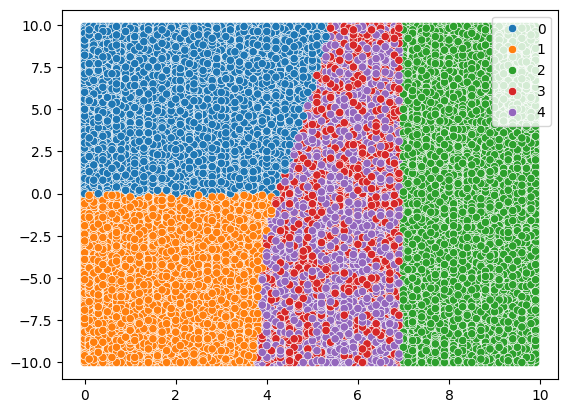

In [14]:
hd_grad = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.18, cluster_selection_method='eom').fit(embeddings_grad)
Labels_grad = hd_grad.labels_

Values_grad = data_grad.values
sns.scatterplot(x=Values_grad[:, 1], y=Values_grad[:, 0], hue=Labels_grad, palette='tab10')

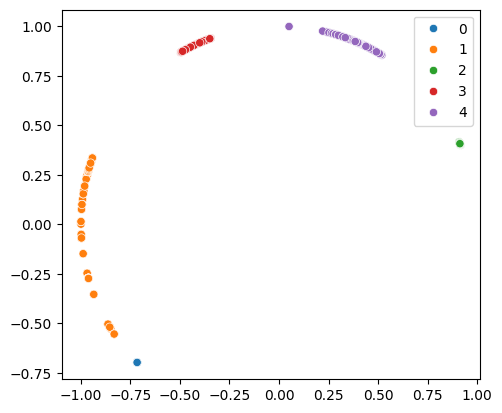

In [15]:
ax = sns.scatterplot(x=embeddings_grad[:, 0], y=embeddings_grad[:, 1], hue=Labels_grad, palette='tab10')
ax.set_aspect('equal')